In [7]:
import random
import math

# Step 1: Load Data
def load_data(filename):
    data = []
    with open(filename, 'r') as file:
        for line in file:
            x, y = map(float, line.strip().split())
            data.append((x, y))
    return data

# Load all classes
class1 = load_data('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class1.txt')
class2 = load_data('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class2.txt')
class3 = load_data('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class3.txt')

# Step 2: Split Data
def split_data(data, train_ratio=0.7):
    train_size = int(train_ratio * len(data))
    train_data = data[:train_size]
    test_data = data[train_size:]
    return train_data, test_data

# Split each class into train/test
train_class1, test_class1 = split_data(class1)
train_class2, test_class2 = split_data(class2)
train_class3, test_class3 = split_data(class3)

# Combine training data and add labels
train_data = [(point, 1) for point in train_class1] + \
             [(point, 2) for point in train_class2] + \
             [(point, 3) for point in train_class3]

test_data = [(point, 1) for point in test_class1] + \
            [(point, 2) for point in test_class2] + \
            [(point, 3) for point in test_class3]

# Step 3: KNN Density Estimation
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def knn_density_estimation(test_point, train_data, k):
    distances = [(euclidean_distance(test_point, train_point[0]), train_point[1]) for train_point in train_data]
    distances.sort()
    k_distances = distances[:k]
    k_th_distance = k_distances[-1][0]
    
    # Density is inversely proportional to the volume defined by k-th nearest distance
    density = 1 / (k_th_distance**2)
    return density, [neighbor[1] for neighbor in k_distances]

# Step 4: Bayes Classification using KNN Density
def classify(test_point, train_data, k):
    densities = {}
    for cls in [1, 2, 3]:
        # Filter training data by class
        class_data = [point for point in train_data if point[1] == cls]
        density, _ = knn_density_estimation(test_point, class_data, k)
        densities[cls] = density
    
    # Assign class based on maximum density (posterior probability)
    return max(densities, key=densities.get)

# Step 5: Evaluate Classifier
def calculate_metrics(predictions, actual_labels, num_classes=3):
    confusion_matrix = [[0] * num_classes for _ in range(num_classes)]
    for pred, actual in zip(predictions, actual_labels):
        confusion_matrix[actual - 1][pred - 1] += 1

    # Calculate precision, recall, F-measure
    metrics = {}
    for cls in range(num_classes):
        tp = confusion_matrix[cls][cls]
        fp = sum(confusion_matrix[row][cls] for row in range(num_classes)) - tp
        fn = sum(confusion_matrix[cls]) - tp
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f_measure = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        metrics[cls + 1] = {"Precision": precision, "Recall": recall, "F-Measure": f_measure}

    accuracy = sum(confusion_matrix[i][i] for i in range(num_classes)) / sum(sum(row) for row in confusion_matrix)
    return accuracy, metrics, confusion_matrix

# Step 6: Run the Experiment
ks = [1, 3, 5, 7]  # Different values of K for the experiment
for k in ks:
    predictions = []
    actual_labels = []S
    for point, true_label in test_data:
        pred_label = classify(point, train_data, k)
        predictions.append(pred_label)
        actual_labels.append(true_label)

    accuracy, metrics, confusion_matrix = calculate_metrics(predictions, actual_labels)
    print(f"K={k}, Accuracy={accuracy}")
    print("Metrics:", metrics)
    print("Confusion Matrix:", confusion_matrix)

    # (Optional) Step 7: Visualize Decision Regions (requires additional plotting code)



K=1, Accuracy=0.9977777777777778
Metrics: {1: {'Precision': 1.0, 'Recall': 1.0, 'F-Measure': 1.0}, 2: {'Precision': 0.9933774834437086, 'Recall': 1.0, 'F-Measure': 0.9966777408637874}, 3: {'Precision': 1.0, 'Recall': 0.9933333333333333, 'F-Measure': 0.9966555183946488}}
Confusion Matrix: [[150, 0, 0], [0, 150, 0], [0, 1, 149]]
K=3, Accuracy=0.9955555555555555
Metrics: {1: {'Precision': 1.0, 'Recall': 0.9933333333333333, 'F-Measure': 0.9966555183946488}, 2: {'Precision': 0.9933774834437086, 'Recall': 1.0, 'F-Measure': 0.9966777408637874}, 3: {'Precision': 0.9933333333333333, 'Recall': 0.9933333333333333, 'F-Measure': 0.9933333333333333}}
Confusion Matrix: [[149, 0, 1], [0, 150, 0], [0, 1, 149]]
K=5, Accuracy=0.9977777777777778
Metrics: {1: {'Precision': 1.0, 'Recall': 1.0, 'F-Measure': 1.0}, 2: {'Precision': 0.9933774834437086, 'Recall': 1.0, 'F-Measure': 0.9966777408637874}, 3: {'Precision': 1.0, 'Recall': 0.9933333333333333, 'F-Measure': 0.9966555183946488}}
Confusion Matrix: [[150, 0

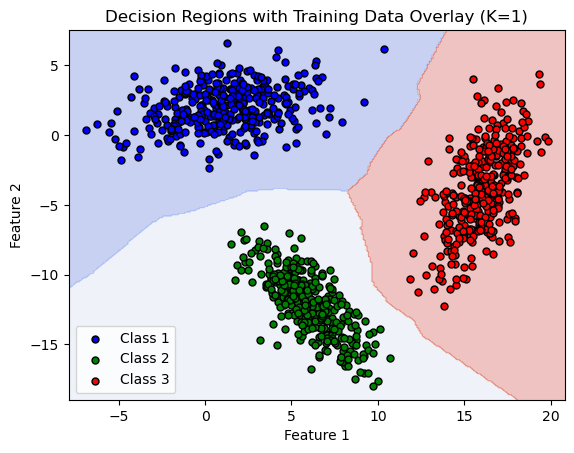

In [21]:
import numpy as np  # Add this import
import matplotlib.pyplot as plt

def visualize_decision_regions(train_data, k):
    # Define the range for the grid
    x_min, x_max = min(point[0][0] for point in train_data) - 1, max(point[0][0] for point in train_data) + 1
    y_min, y_max = min(point[0][1] for point in train_data) - 1, max(point[0][1] for point in train_data) + 1

    # Create a mesh grid of points
    step_size = 0.1  # Smaller step size gives a smoother boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))

    # Predict the class for each point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_labels = [classify((x, y), train_data, k) for x, y in grid_points]
    grid_labels = np.array(grid_labels).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, grid_labels, alpha=0.3, cmap='coolwarm')

    # Overlay the training points for each class
    colors = ['blue', 'green', 'red']
    labels = [1, 2, 3]
    for cls, color in zip(labels, colors):
        class_points = [point[0] for point in train_data if point[1] == cls]
        xs, ys = zip(*class_points)
        plt.scatter(xs, ys, c=color, label=f"Class {cls}", edgecolor='k', s=25)

    # Label and show plot
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Decision Regions with Training Data Overlay (K={k})")
    plt.legend()
    plt.show()

# Call the visualization function
visualize_decision_regions(train_data, k=1)  # Example with k=3


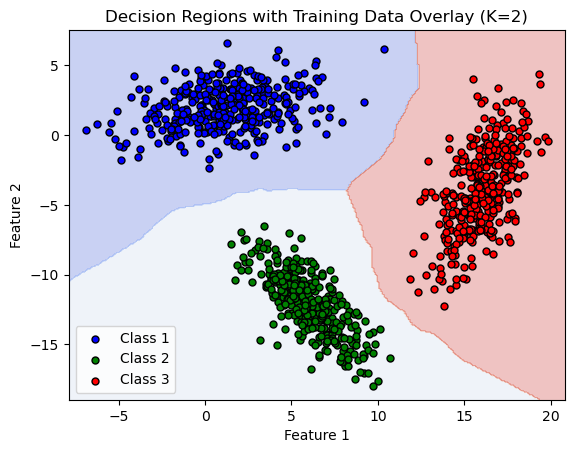

In [23]:
import numpy as np  # Add this import
import matplotlib.pyplot as plt

def visualize_decision_regions(train_data, k):
    # Define the range for the grid
    x_min, x_max = min(point[0][0] for point in train_data) - 1, max(point[0][0] for point in train_data) + 1
    y_min, y_max = min(point[0][1] for point in train_data) - 1, max(point[0][1] for point in train_data) + 1

    # Create a mesh grid of points
    step_size = 0.1  # Smaller step size gives a smoother boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))

    # Predict the class for each point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_labels = [classify((x, y), train_data, k) for x, y in grid_points]
    grid_labels = np.array(grid_labels).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, grid_labels, alpha=0.3, cmap='coolwarm')

    # Overlay the training points for each class
    colors = ['blue', 'green', 'red']
    labels = [1, 2, 3]
    for cls, color in zip(labels, colors):
        class_points = [point[0] for point in train_data if point[1] == cls]
        xs, ys = zip(*class_points)
        plt.scatter(xs, ys, c=color, label=f"Class {cls}", edgecolor='k', s=25)

    # Label and show plot
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Decision Regions with Training Data Overlay (K={k})")
    plt.legend()
    plt.show()

# Call the visualization function
visualize_decision_regions(train_data, k=3)  # Example with k=3


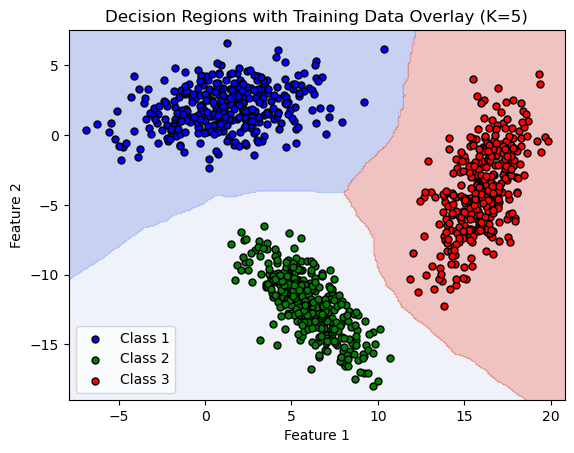

In [25]:
import numpy as np  # Add this import
import matplotlib.pyplot as plt

def visualize_decision_regions(train_data, k):
    # Define the range for the grid
    x_min, x_max = min(point[0][0] for point in train_data) - 1, max(point[0][0] for point in train_data) + 1
    y_min, y_max = min(point[0][1] for point in train_data) - 1, max(point[0][1] for point in train_data) + 1

    # Create a mesh grid of points
    step_size = 0.1  # Smaller step size gives a smoother boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))

    # Predict the class for each point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_labels = [classify((x, y), train_data, k) for x, y in grid_points]
    grid_labels = np.array(grid_labels).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, grid_labels, alpha=0.3, cmap='coolwarm')

    # Overlay the training points for each class
    colors = ['blue', 'green', 'red']
    labels = [1, 2, 3]
    for cls, color in zip(labels, colors):
        class_points = [point[0] for point in train_data if point[1] == cls]
        xs, ys = zip(*class_points)
        plt.scatter(xs, ys, c=color, label=f"Class {cls}", edgecolor='k', s=25)

    # Label and show plot
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Decision Regions with Training Data Overlay (K={k})")
    plt.legend()
    plt.show()

# Call the visualization function
visualize_decision_regions(train_data, k=5)  # Example with k=3


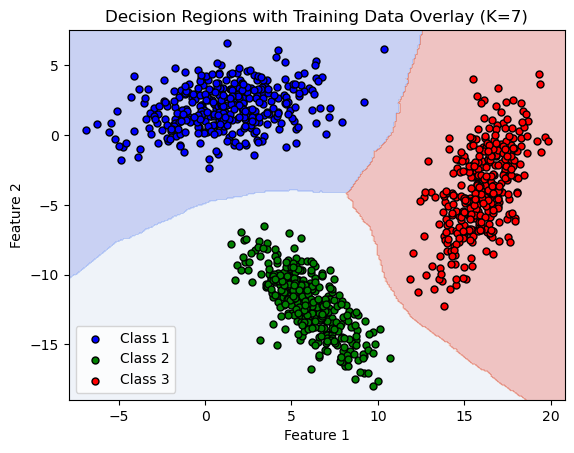

In [26]:
import numpy as np  # Add this import
import matplotlib.pyplot as plt

def visualize_decision_regions(train_data, k):
    # Define the range for the grid
    x_min, x_max = min(point[0][0] for point in train_data) - 1, max(point[0][0] for point in train_data) + 1
    y_min, y_max = min(point[0][1] for point in train_data) - 1, max(point[0][1] for point in train_data) + 1

    # Create a mesh grid of points
    step_size = 0.1  # Smaller step size gives a smoother boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))

    # Predict the class for each point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_labels = [classify((x, y), train_data, k) for x, y in grid_points]
    grid_labels = np.array(grid_labels).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, grid_labels, alpha=0.3, cmap='coolwarm')

    # Overlay the training points for each class
    colors = ['blue', 'green', 'red']
    labels = [1, 2, 3]
    for cls, color in zip(labels, colors):
        class_points = [point[0] for point in train_data if point[1] == cls]
        xs, ys = zip(*class_points)
        plt.scatter(xs, ys, c=color, label=f"Class {cls}", edgecolor='k', s=25)

    # Label and show plot
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Decision Regions with Training Data Overlay (K={k})")
    plt.legend()
    plt.show()

# Call the visualization function
visualize_decision_regions(train_data, k=7)  # Example with k=3
